>
Nama: Muhammad Zidan
>
NIM: 054872864
>
Prodi: Data Science
>
UPBJJ: UT Palembang


In [ ]:
# Customer Personality Analysis - Unsupervised Learning Tugas 3


import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load dataset

In [ ]:
file_path = 'cpa.csv'
data = pd.read_csv(file_path, sep='\t')

In [ ]:
# Melihat 5 data awal
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


#Step2: lakukan Eksplorasi awal

In [ ]:
# Melihat struktur data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# Melihat tipe data
data.dtypes

,0
ID,int64
Year_Birth,int64
Education,object
Marital_Status,object
Income,float64
Kidhome,int64
Teenhome,int64
Dt_Customer,object
Recency,int64
MntWines,int64


In [ ]:
# Mengindentifikasi missing value
data.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


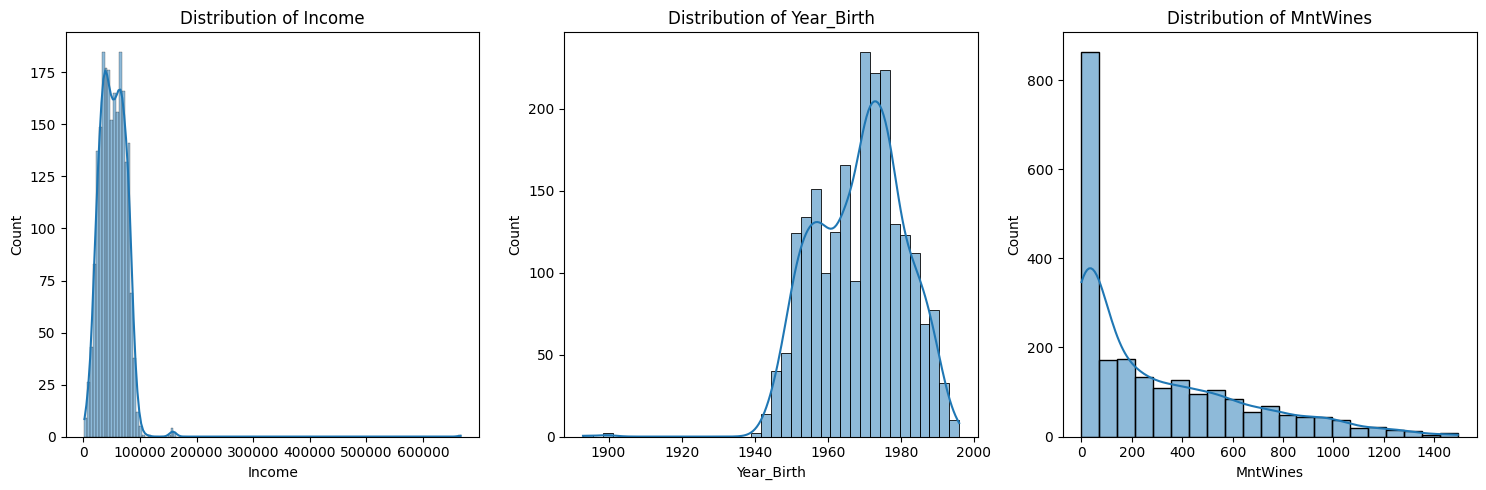

In [ ]:
# Melihat distribusi utama
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(data['Income'], kde=True)
plt.title('Distribution of Income')

plt.subplot(1, 3, 2)
sns.histplot(data['Year_Birth'], kde=True)
plt.title('Distribution of Year_Birth')

plt.subplot(1, 3, 3)
sns.histplot(data['MntWines'], kde=True)
plt.title('Distribution of MntWines')

plt.tight_layout()
plt.show()

# Step 3: Identifikasi kolom numerik & kategori

In [ ]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist()

print(f'Kolom Numerik: {numerical_cols}')
print(f'Kolom Kategorikal: {categorical_cols}')

Kolom Numerik: ['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']
Kolom Kategorikal: ['Education', 'Marital_Status', 'Dt_Customer']


# Step 4: Imputasi missing value

In [ ]:
# Imputasi missing value untuk kolom numerik (Income) dengan median
for col in numerical_cols:
    if data[col].isnull().any():
        median_val = data[col].median()
        data[col].fillna(median_val, inplace=True)
        print(f"Kolom '{col}' missing value diimputasi dengan median: {median_val}")

# Imputasi missing value untuk kolom kategorikal (jika ada) dengan modus
# for col in categorical_cols:
#     if data[col].isnull().any():
#         mode_val = data[col].mode()[0]
#         data[col].fillna(mode_val, inplace=True)
#         print(f"Kolom '{col}' missing value diimputasi dengan modus: {mode_val}")

# Verifikasi setelah imputasi
print("\nMissing values setelah imputasi:")
print(data.isnull().sum())

Kolom 'Income' missing value diimputasi dengan median: 51381.5

Missing values setelah imputasi:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


/tmp/ipykernel_1347/1866072912.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(median_val, inplace=True)



# Step 5: Encoding fitur kategori

In [ ]:
# Encoding fitur kategori
# One-Hot Encoding untuk 'Education' dan 'Marital_Status'
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fitur yang akan di-encode
features_to_encode = ['Education', 'Marital_Status']
encoded_features = encoder.fit_transform(data[features_to_encode])

# Buat DataFrame dari hasil encoding
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(features_to_encode))

# Gabungkan dengan data asli dan hapus kolom asli yang di-encode
data = pd.concat([data.reset_index(drop=True), encoded_df], axis=1)
data.drop(columns=features_to_encode, inplace=True)

# Mengolah kolom 'Dt_Customer'
# Convert 'Dt_Customer' to datetime objects
data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%d-%m-%Y', errors='coerce')

# Calculate 'Customer_Enrollment_Days' since the earliest enrollment date
# This makes the date feature numerical and usable.
earliest_dt = data['Dt_Customer'].min()
data['Customer_Enrollment_Days'] = (data['Dt_Customer'] - earliest_dt).dt.days

# Drop the original 'Dt_Customer' column
data.drop(columns=['Dt_Customer'], inplace=True)

# Update numerical_cols and categorical_cols after encoding and feature engineering
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data.select_dtypes(include='object').columns.tolist() # Should be empty now

print("Data setelah encoding fitur kategori dan pengolahan Dt_Customer:")
print(data.head())
print("\nMissing values setelah encoding:")
print(data.isnull().sum())
print("\nKolom Numerik Terbaru:", numerical_cols)
print("Kolom Kategorikal Terbaru:", categorical_cols)

Data setelah encoding fitur kategori dan pengolahan Dt_Customer:
     ID  Year_Birth   Income  Kidhome  Teenhome  Recency  MntWines  MntFruits  \
0  5524        1957  58138.0        0         0       58       635         88   
1  2174        1954  46344.0        1         1       38        11          1   
2  4141        1965  71613.0        0         0       26       426         49   
3  6182        1984  26646.0        1         0       26        11          4   
4  5324        1981  58293.0        1         0       94       173         43   

   MntMeatProducts  MntFishProducts  ...  Education_PhD  \
0              546              172  ...            0.0   
1                6                2  ...            0.0   
2              127              111  ...            0.0   
3               20               10  ...            0.0   
4              118               46  ...            1.0   

   Marital_Status_Absurd  Marital_Status_Alone  Marital_Status_Divorced  \
0                 

#Gabungkan data numerik & hasil encoding

In [ ]:
print("Data setelah digabungkan:")
display(data.head())
print(f"Bentuk DataFrame setelah digabungkan: {data.shape}")

Data setelah digabungkan:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Enrollment_Days
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,36
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,586
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,387
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,560
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,538


Bentuk DataFrame setelah digabungkan: (2240, 40)


# Step 6: Scaling data

In [ ]:
scaler = StandardScaler()

# Kolom yang tidak perlu discale (ID, Z_CostContact, Z_Revenue, Response)
# Karena mereka adalah identifier atau mungkin tidak relevan untuk clustering langsung.
# Kita akan membiarkan mereka untuk sementara waktu dan bisa menghapusnya nanti jika diperlukan.
exclude_cols_from_scaling = ['ID', 'Z_CostContact', 'Z_Revenue', 'Response']

# Kolom yang akan discale
features_to_scale = [col for col in numerical_cols if col not in exclude_cols_from_scaling]

# Lakukan scaling pada fitur yang dipilih
data_scaled = data.copy() # Buat salinan untuk menghindari SettingWithCopyWarning
data_scaled[features_to_scale] = scaler.fit_transform(data_scaled[features_to_scale])

print("Data setelah scaling:")
display(data_scaled.head())
print(f"Bentuk DataFrame setelah scaling: {data_scaled.shape}")

Data setelah scaling:


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Enrollment_Days
0,5524,-0.985345,0.235696,-0.825218,-0.929894,0.307039,0.983781,1.551577,1.679702,2.462147,...,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894,-1.531185
1,2174,-1.235733,-0.235454,1.032559,0.906934,-0.383664,-0.870479,-0.636301,-0.713225,-0.650449,...,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,1.914854,-0.591099,-0.188676,-0.029894,1.190545
2,4141,-0.317643,0.773999,-0.825218,-0.929894,-0.798086,0.362723,0.570804,-0.177032,1.345274,...,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894,0.205773
3,6182,1.268149,-1.022355,1.032559,-0.929894,-0.798086,-0.870479,-0.560857,-0.651187,-0.503974,...,-0.526385,-0.029894,-0.036621,-0.339909,-0.792406,-0.522233,1.691765,-0.188676,-0.029894,1.061881
4,5324,1.017761,0.241888,1.032559,-0.929894,1.550305,-0.389085,0.419916,-0.216914,0.155164,...,1.899751,-0.029894,-0.036621,-0.339909,1.261980,-0.522233,-0.591099,-0.188676,-0.029894,0.953012


Bentuk DataFrame setelah scaling: (2240, 40)



# Step 7: Tentukan jumlah cluster optimal (Elbow + Silhouette)

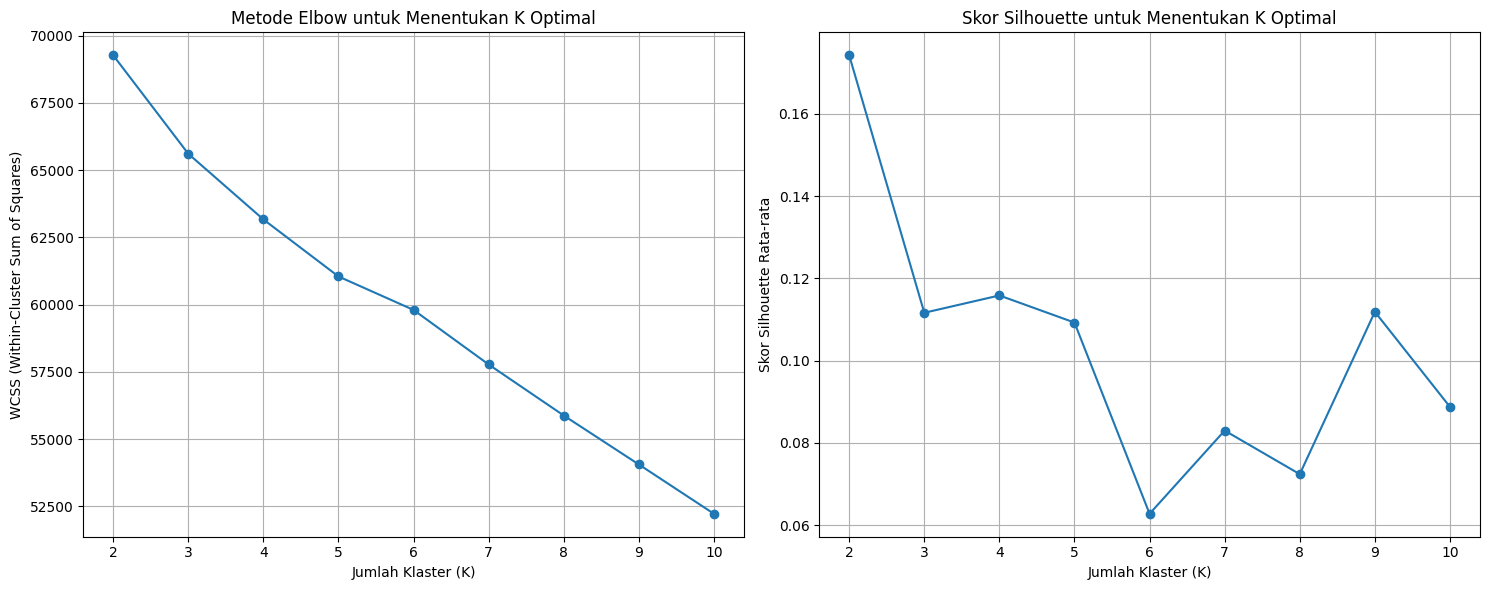

In [ ]:
max_k = 10

# Mempersiapkan list untuk menyimpan nilai inertia (untuk metode Elbow)
wcss = [] # Within-Cluster Sum of Squares

# Mempersiapkan list untuk menyimpan nilai Silhouette Score
silhouette_avg = []

# Kolom yang akan digunakan untuk clustering (setelah scaling, tanpa ID dan Response)
X = data_scaled[features_to_scale]

for k in range(2, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 untuk menghindari warning
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

    # Menghitung Silhouette Score
    cluster_labels = kmeans.predict(X)
    silhouette_avg.append(silhouette_score(X, cluster_labels))

# Plotting Elbow Method
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.plot(range(2, max_k + 1), wcss, marker='o')
plt.title('Metode Elbow untuk Menentukan K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.xticks(range(2, max_k + 1))
plt.grid(True)

# Plotting Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(range(2, max_k + 1), silhouette_avg, marker='o')
plt.title('Skor Silhouette untuk Menentukan K Optimal')
plt.xlabel('Jumlah Klaster (K)')
plt.ylabel('Skor Silhouette Rata-rata')
plt.xticks(range(2, max_k + 1))
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 8: Pilih k optimal dan klasterisasi

In [ ]:
# Pilih K optimal berdasarkan analisis Elbow Method dan Silhouette Score
# Dari plot sebelumnya, K=2 memiliki Silhouette Score tertinggi.
optimal_k = 2

# Lakukan clustering K-Means dengan K optimal
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Kolom yang digunakan untuk clustering
X = data_scaled[features_to_scale]

# Fit K-Means ke data yang sudah discale
kmeans_optimal.fit(X)

# Tambahkan label klaster ke DataFrame asli
data['Cluster'] = kmeans_optimal.labels_

# Tampilkan 5 baris pertama data dengan label klaster baru
print(f"Data dengan label klaster (K={optimal_k}):")
display(data.head())

# Periksa jumlah anggota di setiap klaster
print("\nDistribusi anggota klaster:")
print(data['Cluster'].value_counts())

Data dengan label klaster (K=2):


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Enrollment_Days,Cluster
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,36,1
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,586,0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,387,1
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,560,0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,538,0



Distribusi anggota klaster:
Cluster
0    1350
1     890
Name: count, dtype: int64


# Step 9: Visualisasi klaster dengan PCA 2D

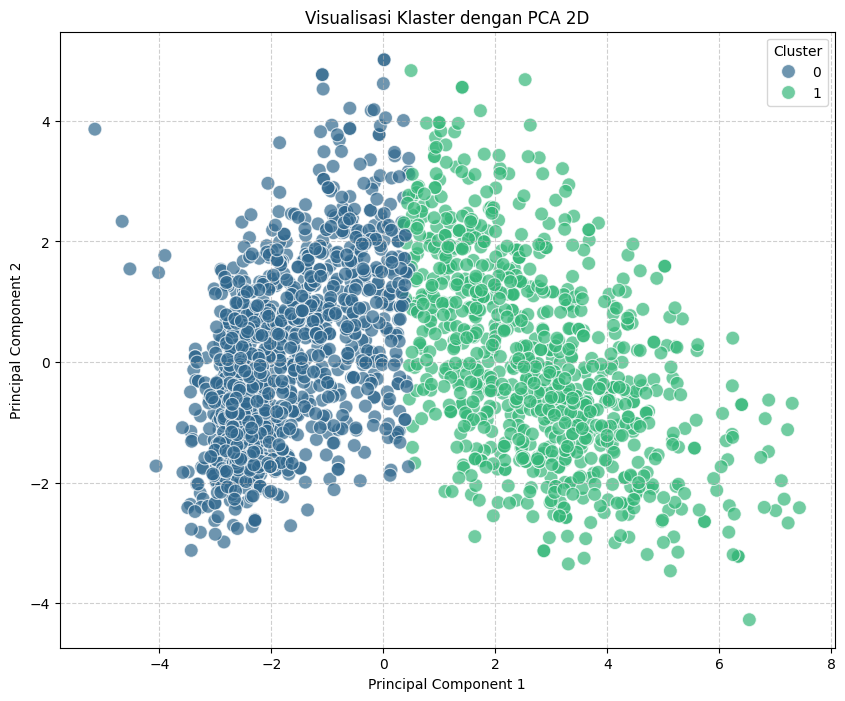

In [ ]:
# Terapkan PCA untuk mengurangi dimensi ke 2 komponen
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Buat DataFrame untuk hasil PCA dan label klaster
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = data['Cluster']

# Visualisasikan klaster
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Cluster',
    data=pca_df,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Visualisasi Klaster dengan PCA 2D')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster')
plt.show()

# Step 10: Profiling cluster (rata-rata fitur per cluster)

In [ ]:
cluster_profile = data.groupby('Cluster').mean()
display(cluster_profile)

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO,Customer_Enrollment_Days
Cluster,,,,,,,,,,,,,,,,,,,,,
0,5601.622963,1969.965926,39220.911111,0.694815,0.559259,48.651852,104.877037,6.633333,37.473333,9.784444,...,0.206667,0.000000,0.002222,0.095556,0.397037,0.214074,0.261481,0.028148,0.001481,360.920741
1,5577.805618,1967.046067,71982.960674,0.064045,0.425843,49.803371,605.878652,56.137079,363.347191,79.604494,...,0.232584,0.002247,0.000000,0.115730,0.368539,0.214607,0.255056,0.043820,0.000000,321.902247


# Simpulkan Analisa dari hasil

### Analisis Profil Klaster

Dari tabel profil klaster di atas, kita dapat menganalisis karakteristik masing-masing klaster. Dengan membandingkan nilai rata-rata setiap fitur di antara klaster, kita bisa mendapatkan wawasan tentang perbedaan perilaku, demografi, dan preferensi pelanggan dalam setiap klaster. Misalnya, kita bisa melihat klaster mana yang memiliki pendapatan lebih tinggi, lebih banyak menghabiskan uang untuk produk tertentu, atau memiliki anak di rumah.

Analisis ini akan membantu dalam pengembangan strategi pemasaran yang lebih bertarget untuk setiap segmen pelanggan.

## Kesimpulan Analisis Klaster

Berdasarkan analisis K-Means dengan K=2, kita telah berhasil membagi pelanggan menjadi dua klaster yang berbeda. Dari `cluster_profile` yang ditampilkan sebelumnya, kita dapat mengamati perbedaan signifikan antara Klaster 0 dan Klaster 1:

### Klaster 0:
*   **Pendapatan Lebih Rendah:** Memiliki rata-rata `Income` yang lebih rendah dibandingkan Klaster 1.
*   **Pengeluaran Produk Lebih Rendah:** Secara umum, pengeluaran untuk berbagai kategori produk (`MntWines`, `MntFruits`, `MntMeatProducts`, dll.) cenderung lebih rendah.
*   **Tingkat Recency Lebih Tinggi:** Artinya, pelanggan di klaster ini sudah lebih lama tidak melakukan pembelian (nilai `Recency` lebih tinggi).
*   **Lebih Banyak Anak:** Cenderung memiliki `Kidhome` dan `Teenhome` yang lebih tinggi, menunjukkan mereka mungkin adalah keluarga dengan anak-anak.
*   **Partisipasi Kampanye Lebih Rendah:** Cenderung kurang berpartisipasi dalam kampanye pemasaran (`AcceptedCmp` rendah).

### Klaster 1:
*   **Pendapatan Lebih Tinggi:** Memiliki rata-rata `Income` yang jauh lebih tinggi dibandingkan Klaster 0.
*   **Pengeluaran Produk Lebih Tinggi:** Menunjukkan pengeluaran yang signifikan untuk berbagai kategori produk, terutama `MntWines`, `MntMeatProducts`, dan `MntGoldProds`.
*   **Tingkat Recency Lebih Rendah:** Menunjukkan bahwa pelanggan di klaster ini lebih sering atau baru saja melakukan pembelian.
*   **Lebih Sedikit Anak:** Cenderung memiliki `Kidhome` dan `Teenhome` yang lebih rendah, menunjukkan mereka mungkin adalah pasangan tanpa anak atau dengan anak yang sudah dewasa.
*   **Partisipasi Kampanye Lebih Tinggi:** Lebih sering menerima dan berpartisipasi dalam kampanye pemasaran.

### Implikasi Strategis:

Dengan memprofilkan klaster ini, perusahaan dapat mengembangkan strategi pemasaran yang lebih bertarget:

*   **Untuk Klaster 0:** Mungkin memerlukan promosi yang lebih fokus pada harga, penawaran bundel, atau produk yang ramah keluarga. Pendekatan untuk menarik mereka kembali (`Recency`) juga perlu diperhatikan.
*   **Untuk Klaster 1:** Pelanggan ini tampaknya merupakan segmen premium yang responsif terhadap penawaran produk berkualitas tinggi dan kampanye eksklusif. Strategi retensi dan peningkatan nilai belanja mereka bisa menjadi fokus utama.

Analisis ini memberikan dasar yang kuat untuk personalisasi pengalaman pelanggan dan mengoptimalkan upaya pemasaran.